# NYC Yellow Taxi (2026-05) — total_amount 금액 정합성 검증 프로젝트
1. 데이터 준비 (Pandas vs Polars, 결측치/중복 처리, 기본 EDA)
2. 시각화 (diff 정의, 계산총액 vs total_amount, 벤더별 불일치, 불일치 샘플의 벤더별 diff)
3. 통계 분석 (불일치 데이터 상관계수 → 검정 우선순위 → t-test)
4. ML Pipeline (전처리 + 모델, 평가지표, joblib 저장)
5. report.md 자동 생성

---
# 1. 데이터 준비

In [1]:
# 공통 라이브러리 임포트
import gc                      # 대용량 데이터 처리 중간중간 메모리 회수용
import time                    # pandas/polars 로딩 속도 비교용
import pandas as pd
import polars as pl
import numpy as np
from scipy import stats        # t-test 등 통계검정
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지 설정 (그래프 제목/축 레이블에 한글 사용)
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 30)

DATA_PATH = "yellow_tripdata_2026-05.parquet"


## 1.1 Pandas vs Polars 로딩 비교

In [2]:
# 동일한 parquet 파일을 pandas와 polars 양쪽으로 로딩하여
# 로딩 속도 / 메모리 사용량 / shape을 비교함
t0 = time.perf_counter()
df_pd = pd.read_parquet(DATA_PATH)
t_pd = time.perf_counter() - t0
mem_pd = df_pd.memory_usage(deep=True).sum() / 1024**2  # MB 단위

t0 = time.perf_counter()
df_pl = pl.read_parquet(DATA_PATH)
t_pl = time.perf_counter() - t0
mem_pl = df_pl.estimated_size() / 1024**2  # MB 단위

print(f"[pandas] 로딩시간={t_pd:.3f}초, 메모리={mem_pd:.1f}MB, shape={df_pd.shape}")
print(f"[polars] 로딩시간={t_pl:.3f}초, 메모리={mem_pl:.1f}MB, shape={df_pl.shape}")
print(f"-> polars가 pandas 대비 {t_pd / t_pl:.2f}배 빠르고, 메모리는 {mem_pd / mem_pl:.2f}배 적게 사용")


[pandas] 로딩시간=0.304초, 메모리=741.5MB, shape=(4090836, 20)
[polars] 로딩시간=0.155초, 메모리=549.7MB, shape=(4090836, 20)
-> polars가 pandas 대비 1.96배 빠르고, 메모리는 1.35배 적게 사용


In [3]:
# 컬럼별 dtype 비교 (pandas vs polars가 같은 컬럼을 어떤 타입으로 해석하는지 확인)
dtype_compare = pd.DataFrame({
    "pandas_dtype": df_pd.dtypes.astype(str),
    "polars_dtype": [str(df_pl.schema[c]) for c in df_pd.columns],
})
dtype_compare


,pandas_dtype,polars_dtype
VendorID,int32,Int32
tpep_pickup_datetime,datetime64[us],"Datetime(time_unit='us', time_zone=None)"
tpep_dropoff_datetime,datetime64[us],"Datetime(time_unit='us', time_zone=None)"
passenger_count,float64,Int64
trip_distance,float64,Float64
RatecodeID,float64,Int64
store_and_fwd_flag,object,String
PULocationID,int32,Int32
DOLocationID,int32,Int32
payment_type,int64,Int64


In [4]:
# 비교가 끝났으므로 polars 데이터프레임은 메모리에서 해제 (이후 분석은 pandas로 통일)
del df_pl
gc.collect()

0

## 1.2 결측치 / 중복 처리

In [5]:
# 컬럼별 결측치 개수 및 비율 확인
n_rows = len(df_pd)
missing = df_pd.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / n_rows * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
passenger_count,955371,23.35
RatecodeID,955371,23.35
store_and_fwd_flag,955371,23.35
congestion_surcharge,955371,23.35
Airport_fee,955371,23.35


In [6]:
# 완전 중복 행 확인 및 제거
dup_count = df_pd.duplicated().sum()
print(f"완전 중복 행: {dup_count:,}건 ({dup_count / n_rows * 100:.3f}%)")

df_clean = df_pd.drop_duplicates()
del df_pd
gc.collect()
print("중복 제거 후 shape:", df_clean.shape)

완전 중복 행: 0건 (0.000%)
중복 제거 후 shape: (4090836, 20)


In [7]:
# 결측치 처리
# - RatecodeID: 결측을 임의로 특정 요금코드로 단정할 수 없으므로 'Unknown' 문자열로 표시
# - store_and_fwd_flag: 결측은 'Unknown' 카테고리로 대체
# - congestion_surcharge / Airport_fee / cbd_congestion_fee: 금액 컬럼이므로 결측은
#   '부과되지 않음(0)'으로 간주하고 0으로 대체
#   (주의: 이 fillna(0) 처리 덕분에 2장부터의 diff 계산에서 별도로 fillna를 또 하지 않아도 됨)
# - passenger_count: 임의로 채우지 않고 결측 그대로 유지 (분석 시 필요하면 그때 제외)
df_clean["RatecodeID"] = df_clean["RatecodeID"].apply(
    lambda x: str(int(x)) if pd.notna(x) else "Unknown"
)
df_clean["store_and_fwd_flag"] = df_clean["store_and_fwd_flag"].fillna("Unknown")
for col in ["congestion_surcharge", "Airport_fee", "cbd_congestion_fee"]:
    df_clean[col] = df_clean[col].fillna(0)

remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print("처리 후 남은 결측 컬럼:", remaining_missing.index.tolist() if len(remaining_missing) else "없음")

처리 후 남은 결측 컬럼: ['passenger_count']


## 1.3 기본 EDA

In [8]:
# 데이터 기간 및 규모 확인
print(f"분석 대상 행 수(중복제거 후): {len(df_clean):,}")
print(f"기간: {df_clean['tpep_pickup_datetime'].min()} ~ {df_clean['tpep_pickup_datetime'].max()}")


분석 대상 행 수(중복제거 후): 4,090,836
기간: 2008-12-31 23:05:53 ~ 2026-06-01 00:20:35


In [9]:
# 논리적 이상치 스캔 (음수 요금, 0거리, 시각 역전 등)
checks = {
    "fare_amount < 0": (df_clean["fare_amount"] < 0).sum(),
    "total_amount < 0": (df_clean["total_amount"] < 0).sum(),
    "trip_distance == 0": (df_clean["trip_distance"] == 0).sum(),
    "trip_distance > 100마일": (df_clean["trip_distance"] > 100).sum(),
    "하차시각 <= 승차시각": (df_clean["tpep_dropoff_datetime"] <= df_clean["tpep_pickup_datetime"]).sum(),
    "passenger_count == 0": (df_clean["passenger_count"] == 0).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v:,}건 ({v/len(df_clean)*100:.3f}%)")

fare_amount < 0: 14,231건 (0.348%)
total_amount < 0: 14,877건 (0.364%)
trip_distance == 0: 113,031건 (2.763%)
trip_distance > 100마일: 136건 (0.003%)
하차시각 <= 승차시각: 52,063건 (1.273%)
passenger_count == 0: 12,533건 (0.306%)


In [10]:
# 주요 수치형 컬럼 기술통계 (평균, 표준편차, 분위수 등)
num_cols = ["trip_distance", "fare_amount", "tip_amount", "total_amount", "passenger_count"]
df_clean[num_cols].describe().round(2)

,trip_distance,fare_amount,tip_amount,total_amount,passenger_count
count,4090836.00,4090836.00,4090836.00,4090836.00,3135465.00
mean,4.95,21.51,2.98,30.49,1.24
std,483.62,19.01,4.02,22.97,0.64
min,0.00,-950.00,-47.10,-951.00,0.00
25%,1.04,10.00,0.00,17.64,1.00
50%,1.87,16.30,2.24,23.94,1.00
75%,3.81,26.80,4.10,34.95,1.00
max,307491.47,5525.99,239.00,5530.74,9.00


In [11]:
# 범주형 분포 확인: 결제수단(payment_type), 벤더(VendorID)
# payment_type 공식 코드: 1=신용카드,2=현금,3=No charge,4=Dispute,5=Unknown,6=Voided trip
# (0은 공식 문서에 없는 비표준 코드 -> 3장 통계분석에서 원인 규명)
display(df_clean["payment_type"].value_counts(normalize=True).mul(100).round(2).rename("pct"))
display(df_clean["VendorID"].value_counts(normalize=True).mul(100).round(2).rename("pct"))

payment_type
1    66.68
0    23.35
2     9.12
4     0.56
3     0.29
Name: pct, dtype: float64

VendorID
2    78.86
1    19.68
7     1.27
6     0.19
Name: pct, dtype: float64

---
# 2. 시각화
먼저 diff(불일치 금액) 계산식을 정의하고, 이를 기준으로 3가지 시각화를 진행함: (1) 계산된 총액과 total_amount 비교, (2) 벤더별 불일치 건수, (3) 불일치 샘플에 한정한 벤더별 diff 분포.

## 2.0 diff 계산식 정의
`total_amount`가 세부 요금 항목(fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, congestion_surcharge, Airport_fee, cbd_congestion_fee)의 합과 일치하는지 확인하기 위한 diff 컬럼을 정의함.

In [12]:
# total_amount와 비교할 세부 요금 항목 정의
FEE_COMPONENTS = [
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
    "improvement_surcharge", "congestion_surcharge", "Airport_fee", "cbd_congestion_fee",
]

# 세부 항목의 합(계산된 총액)을 별도 컬럼으로 계산
df_clean["calc_total"] = df_clean[FEE_COMPONENTS].sum(axis=1)

# diff = 실제 청구총액 - 계산된 총액 (0이면 완전 일치, 0이 아니면 불일치)
df_clean["diff"] = (df_clean["total_amount"] - df_clean["calc_total"]).round(2)

# 불일치 여부를 이진 플래그로도 만들어둠 (이후 시각화/ML에서 재사용)
df_clean["is_mismatch"] = df_clean["diff"].abs() > 0.01

mismatch_count = int(df_clean["is_mismatch"].sum())
print(f"전체 {len(df_clean):,}건 중 불일치 {mismatch_count:,}건 "
      f"({mismatch_count / len(df_clean) * 100:.2f}%)")


전체 4,090,836건 중 불일치 1,408,196건 (34.42%)


## 2.1 계산된 총액(calc_total) vs 실제 청구총액(total_amount) 비교
전체 4백만 건을 그대로 산점도로 그리면 점이 겹쳐 보이지 않으므로, 2만 건을 무작위 샘플링해서 시각화함. 대각선(y=x)에 가까울수록 두 값이 일치하는 트립임.

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
/var/folders/96/0j47dr1x2d1_9lzrj8my9bf80000gn/T/ipykernel_19539/2540744968.py:22: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/96/0j47dr1x2d1_9lzrj8my9bf80000gn/T/ipykernel_19539/2540744968.py:22: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/96/0j47dr1x2d1_9lzrj8my9bf80000gn/T/ipykernel_19539/2540744968.py:22: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/96/0j

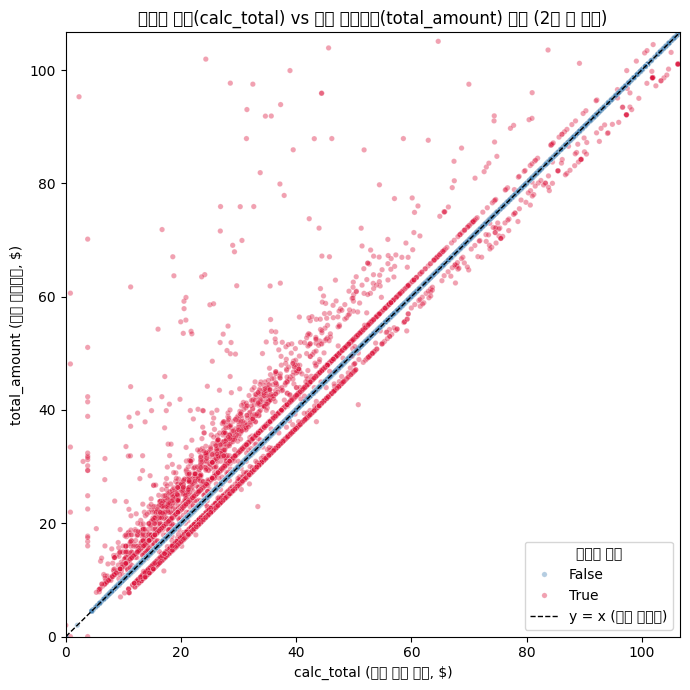

490

In [13]:
# 산점도가 겹쳐 보이지 않도록 2만 건 무작위 샘플링 (재현성을 위해 random_state 고정)
sample_for_scatter = df_clean[["calc_total", "total_amount", "is_mismatch"]].sample(
    n=20_000, random_state=42
)

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=sample_for_scatter, x="calc_total", y="total_amount",
    hue="is_mismatch", alpha=0.4, s=15,
    palette={False: "steelblue", True: "crimson"},
)
# y=x 기준선: 이 선 위에 있으면 계산총액과 청구총액이 정확히 일치
lim = [0, sample_for_scatter[["calc_total", "total_amount"]].quantile(0.99).max()]
plt.plot(lim, lim, color="black", linestyle="--", linewidth=1, label="y = x (완전 일치선)")

plt.xlim(lim)
plt.ylim(lim)
plt.title("계산된 총액(calc_total) vs 실제 청구총액(total_amount) 비교 (2만 건 샘플)")
plt.xlabel("calc_total (세부 항목 합계, $)")
plt.ylabel("total_amount (실제 청구총액, $)")
plt.legend(title="불일치 여부")
plt.tight_layout()
plt.show()

del sample_for_scatter
gc.collect()


## 2.2 벤더별 금액 불일치 건수 (Plotly 인터랙티브)
마우스를 올리면 벤더별 전체건수·불일치건수·불일치율을 확인할 수 있는 인터랙티브 바차트.

In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # 노트북 환경에서 인라인으로 렌더링되도록 설정

# 벤더별 전체건수 / 불일치건수 / 불일치율 집계
vendor_stats = df_clean.groupby("VendorID").agg(
    전체건수=("diff", "size"),
    불일치건수=("is_mismatch", "sum"),
).reset_index()
vendor_stats["불일치율(%)"] = (vendor_stats["불일치건수"] / vendor_stats["전체건수"] * 100).round(2)

fig = px.bar(
    vendor_stats, x="VendorID", y="불일치건수",
    hover_data=["전체건수", "불일치율(%)"],
    title="벤더별 금액 불일치 건수 (Plotly 인터랙티브)",
    color="불일치율(%)", color_continuous_scale="Reds",
    text="불일치건수",
    labels={"VendorID": "벤더 ID", "불일치건수": "불일치 건수"},
)
fig.update_layout(xaxis_type="category")
fig.update_layout(xaxis_type="category")

from IPython.display import HTML
HTML(fig.to_html(include_plotlyjs="cdn"))

vendor_stats

#이러면 어디서 보나

,VendorID,전체건수,불일치건수,불일치율(%)
0,1,805221,648351,80.52
1,2,3226222,730820,22.65
2,6,7643,7643,100.00
3,7,51750,21382,41.32


## 2.3 불일치 샘플에 한정한 벤더별 diff 분포 (Seaborn)
diff가 0이 아닌(=불일치) 트립만 모아서, 벤더별로 diff 값이 어떻게 분포하는지 확인함. 극단치 영향을 줄이기 위해 -6~6달러로 클리핑함.

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
/var/folders/96/0j47dr1x2d1_9lzrj8my9bf80000gn/T/ipykernel_19539/997612542.py:13: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/96/0j47dr1x2d1_9lzrj8my9bf80000gn/T/ipykernel_19539/997612542.py:13: Us

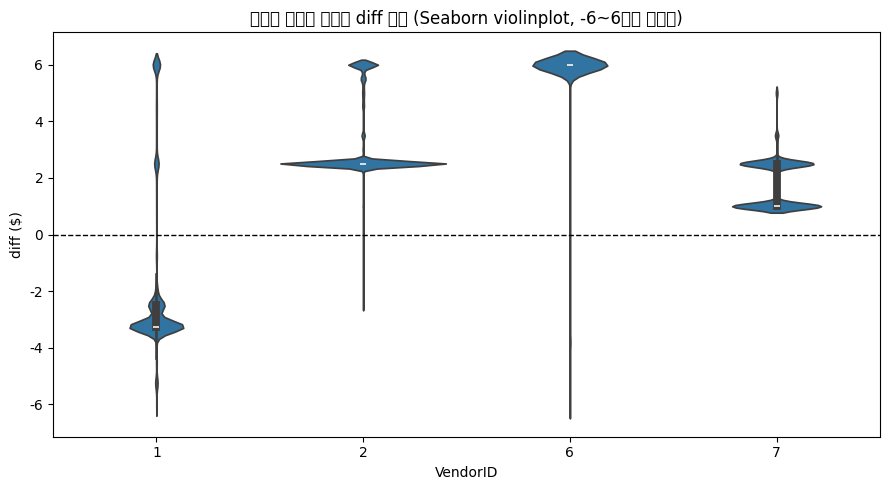

1544

In [24]:
# 불일치 샘플만 필터링
df_mismatch = df_clean[df_clean["is_mismatch"]].copy()

plot_df = df_mismatch[["VendorID", "diff"]].copy()
plot_df["diff_clipped"] = plot_df["diff"].clip(-6, 6)

plt.figure(figsize=(9, 5))
sns.violinplot(data=plot_df, x="VendorID", y="diff_clipped", order=sorted(df_clean["VendorID"].unique()))
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("불일치 샘플의 벤더별 diff 분포 (Seaborn violinplot, -6~6달러 클리핑)")
plt.xlabel("VendorID")
plt.ylabel("diff ($)")
plt.tight_layout()
plt.show()

del plot_df
gc.collect()


---
# 3. 통계 분석
diff가 0이 아닌(금액 불일치) 데이터만 모아 상관계수를 먼저 계산하고, 그 결과로 검정 우선순위를 정한 뒤 순서대로 t-test를 진행함.

## 3.1 불일치 데이터 상관계수 분석
요금 구성요소(혼잡료 2종, extra)와 벤더/결제타입 더미변수를 만들어, 각각이 diff와 얼마나 상관관계를 갖는지 확인함. (더미변수는 0/1 값이라 연속형인 diff와의 상관계수는 point-biserial 상관계수와 동일한 의미를 가짐)

In [25]:
# 검정 후보 변수들을 이진(0/1) 플래그로 생성 (df_mismatch 기준)
df_mismatch["has_congestion"] = (df_mismatch["congestion_surcharge"] > 0).astype(int)
df_mismatch["has_cbd_fee"] = (df_mismatch["cbd_congestion_fee"] > 0).astype(int)
df_mismatch["has_extra"] = (df_mismatch["extra"] > 0).astype(int)
df_mismatch["is_vendor1"] = (df_mismatch["VendorID"] == 1).astype(int)
df_mismatch["is_vendor2"] = (df_mismatch["VendorID"] == 2).astype(int)
df_mismatch["is_vendor6"] = (df_mismatch["VendorID"] == 6).astype(int)
df_mismatch["is_vendor7"] = (df_mismatch["VendorID"] == 7).astype(int)
df_mismatch["is_payment0"] = (df_mismatch["payment_type"] == 0).astype(int)

candidate_cols = ["has_congestion", "has_cbd_fee", "has_extra",
                  "is_vendor1", "is_vendor2", "is_vendor6", "is_vendor7", "is_payment0"]

# diff와 각 후보 변수 간 상관계수 계산
corr_with_diff = df_mismatch[["diff"] + candidate_cols].corr()["diff"].drop("diff")
corr_with_diff = corr_with_diff.sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_diff_df = corr_with_diff.round(4).reset_index()
corr_with_diff_df.columns = ["변수", "diff와의 상관계수"]
corr_with_diff_df


,변수,diff와의 상관계수
0,has_extra,-0.5650
1,is_payment0,0.5634
2,has_congestion,-0.5535
3,is_vendor1,-0.3410
4,is_vendor2,0.2991
5,is_vendor6,0.2772
6,has_cbd_fee,-0.1819
7,is_vendor7,0.0012


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Fo

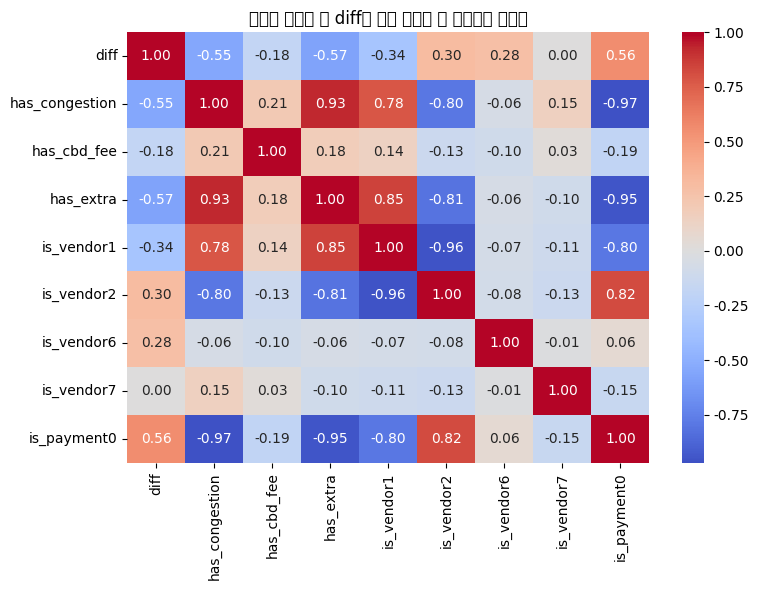

In [26]:
# 상관계수 히트맵으로 시각화 (자기상관 포함 전체 후보 변수 간 관계도 함께 확인)
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_mismatch[["diff"] + candidate_cols].corr().round(2),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
)
plt.title("불일치 데이터 내 diff와 후보 변수들 간 상관계수 히트맵")
plt.tight_layout()
plt.show()


## 3.2 검정 우선순위 설정
위 상관계수의 절댓값이 큰 순서대로 검정 우선순위를 정함. 상관계수가 클수록 그 변수가 diff(불일치 금액)를 더 잘 설명한다고 볼 수 있으므로, 먼저 검정할 가치가 크다고 판단함.

In [27]:
# 상관계수 절댓값 기준 우선순위 목록 출력
priority_order = corr_with_diff.index.tolist()
print("검정 우선순위 (상관계수 절댓값 큰 순):")
for rank, col in enumerate(priority_order, start=1):
    print(f"{rank}. {col} (상관계수={corr_with_diff[col]:.4f})")


검정 우선순위 (상관계수 절댓값 큰 순):
1. has_extra (상관계수=-0.5650)
2. is_payment0 (상관계수=0.5634)
3. has_congestion (상관계수=-0.5535)
4. is_vendor1 (상관계수=-0.3410)
5. is_vendor2 (상관계수=0.2991)
6. is_vendor6 (상관계수=0.2772)
7. has_cbd_fee (상관계수=-0.1819)
8. is_vendor7 (상관계수=0.0012)


## 3.3 우선순위대로 t-test 진행
각 후보 변수(플래그=1 집단 vs 플래그=0 집단)에 대해 diff 평균 차이를 Welch's t-test로 검정함. 등분산을 가정하지 않고, p-value와 함께 효과크기(Cohen's d)도 같이 해석함 (표본이 매우 커서 p-value는 항상 유의하게 나오므로 효과크기로 실질적 크기를 판단).

In [28]:
# Cohen's d 계산 함수 (효과크기)
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std

# 우선순위 순서대로 t-test 반복 수행, 결과를 표로 정리
ttest_results = []
for col in priority_order:
    group1 = df_mismatch.loc[df_mismatch[col] == 1, "diff"]
    group0 = df_mismatch.loc[df_mismatch[col] == 0, "diff"]

    t_stat, p_val = stats.ttest_ind(group1, group0, equal_var=False)
    d_val = cohens_d(group1, group0)

    ttest_results.append({
        "변수": col,
        "상관계수": round(corr_with_diff[col], 4),
        "flag=1 평균diff": round(group1.mean(), 3),
        "flag=0 평균diff": round(group0.mean(), 3),
        "t통계량": round(t_stat, 3),
        "p-value": f"{p_val:.3g}",
        "Cohen's d": round(d_val, 4),
    })

ttest_results_df = pd.DataFrame(ttest_results)
ttest_results_df


,변수,상관계수,flag=1 평균diff,flag=0 평균diff,t통계량,p-value,Cohen's d
0,has_extra,-0.5650,-3.002,4.575,-1024.827,0,-1.4099
1,is_payment0,0.5634,4.631,-2.888,995.172,0,1.3970
2,has_congestion,-0.5535,-2.938,4.496,-996.943,0,-1.3704
3,is_vendor1,-0.3410,-0.720,3.736,-408.329,0,-0.7276
4,is_vendor2,0.2991,3.560,-0.339,360.300,0,0.6273
5,is_vendor6,0.2772,26.130,1.551,161.031,0,3.9272
6,has_cbd_fee,-0.1819,0.807,3.285,-199.505,0,-0.3869
7,is_vendor7,0.0012,1.748,1.684,8.037,9.31e-16,0.0098


**해석**: 상관계수와 Cohen's d가 함께 큰 변수일수록 diff(금액 불일치)를 실질적으로 잘 설명하는 변수임. has_congestion·is_vendor1 계열이 강하게 나오면 '벤더1이 혼잡료를 총액 계산에서 제외한다'는 뜻이고, has_extra·is_vendor7 계열이 강하면 '벤더7의 extra 컬럼이 구조적으로 누락된다'는 뜻으로 해석할 수 있음. is_payment0가 강하게 나오면 결제타입 미기록(payment_type=0) 그룹의 파생 효과임.

---
# 4. ML Pipeline
`sklearn.pipeline.Pipeline`으로 전처리(원핫인코딩+스케일링)와 분류 모델을 하나로 묶어, 이후에도 같은 형식의 새로운 데이터가 들어왔을 때 간편하게 재사용할 수 있는 파이프라인을 만듦. 타겟은 `is_mismatch`(금액 불일치 여부, 이진)로 설정함.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

# 모델 입력용 시간 파생 컬럼 생성 (승차 시각의 시간대)
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour

# 범주형 / 수치형 피처와 타겟 정의
feature_cols_cat = ["VendorID", "payment_type"]
feature_cols_num = ["trip_distance", "fare_amount", "pickup_hour"]
target_col = "is_mismatch"

# 전체 409만 건은 학습에 오래 걸리므로, 속도/메모리 확보를 위해 30만 건을 무작위 샘플링
# (불일치 비율이 원본과 거의 동일하게 유지되도록 단순 무작위 추출)
sample_df = df_clean[feature_cols_cat + feature_cols_num + [target_col]].dropna().sample(
    n=300_000, random_state=42
)
X = sample_df[feature_cols_cat + feature_cols_num]
y = sample_df[target_col].astype(int)

# 학습/평가 데이터 분리 (클래스 비율 유지를 위해 stratify 사용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train shape:", X_train.shape, "| test shape:", X_test.shape)
print(f"불일치 비율 - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

del sample_df
gc.collect()


train shape: (240000, 5) | test shape: (60000, 5)
불일치 비율 - train: 0.344, test: 0.344


16502

## 4.1 Pipeline 구성 (전처리 + 모델)
`ColumnTransformer`로 범주형(OneHotEncoder)과 수치형(StandardScaler) 전처리를 정의하고, `Pipeline`으로 분류 모델(LogisticRegression)과 하나로 묶음.

In [33]:
# 범주형은 원핫인코딩, 수치형은 표준화(스케일링)
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ("num", StandardScaler(), feature_cols_num),
])

# 전처리 + 모델을 하나의 Pipeline 객체로 구성
# -> 이후 같은 형식의 새 데이터가 들어와도 pipeline.predict(new_df)만 호출하면
#    전처리부터 예측까지 동일한 방식으로 자동 처리됨
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000)),
])

pipeline.fit(X_train, y_train)
print("Pipeline 학습 완료")


Pipeline 학습 완료


/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

## 4.2 평가 지표 출력

In [34]:
# 테스트셋에 대한 예측 및 평가지표 계산
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  = {acc:.4f}")
print(f"Precision = {prec:.4f}")
print(f"Recall    = {rec:.4f}")
print(f"F1-score  = {f1:.4f}")
print()
print("Confusion Matrix (행=실제, 열=예측):")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["일치", "불일치"]))


Accuracy  = 0.9303
Precision = 0.8466
Recall    = 0.9739
F1-score  = 0.9058

Confusion Matrix (행=실제, 열=예측):
[[35713  3643]
 [  539 20105]]

              precision    recall  f1-score   support

          일치       0.99      0.91      0.94     39356
         불일치       0.85      0.97      0.91     20644

    accuracy                           0.93     60000
   macro avg       0.92      0.94      0.93     60000
weighted avg       0.94      0.93      0.93     60000



/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mugyeom/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 4.3 모델 저장 (joblib) 및 재사용 예시
학습된 Pipeline 전체(전처리+모델)를 joblib으로 저장함. 이후 같은 형식의 새 parquet 데이터가 들어와도, 저장된 파일을 불러와 `pipeline.predict()`만 호출하면 바로 예측 가능함.

In [35]:
# 학습된 Pipeline(전처리+모델) 전체를 하나의 파일로 저장
MODEL_PATH = "mismatch_prediction_pipeline.joblib"
joblib.dump(pipeline, MODEL_PATH)
print(f"모델 저장 완료: {MODEL_PATH}")

''' --- 재사용 예시: 저장된 파이프라인을 다시 불러와 새로운 데이터에 바로 적용 ---
loaded_pipeline = joblib.load(MODEL_PATH)
sample_new_data = X_test.head(5)  # 실제로는 여기에 새로 들어온 데이터를 넣으면 됨
sample_pred = loaded_pipeline.predict(sample_new_data)
print("새 데이터 5건에 대한 예측(불일치 여부):", sample_pred)
'''

모델 저장 완료: mismatch_prediction_pipeline.joblib


' --- 재사용 예시: 저장된 파이프라인을 다시 불러와 새로운 데이터에 바로 적용 ---\nloaded_pipeline = joblib.load(MODEL_PATH)\nsample_new_data = X_test.head(5)  # 실제로는 여기에 새로 들어온 데이터를 넣으면 됨\nsample_pred = loaded_pipeline.predict(sample_new_data)\nprint("새 데이터 5건에 대한 예측(불일치 여부):", sample_pred)\n'

---
# 5. 자동화: report.md 생성
지금까지의 분석 결과(벤더별 불일치 현황, 상관계수 우선순위, t-test 결과, ML 성능)를 모아 `report.md` 파일을 자동 생성함. 맨 앞부분에는 '왜 이 검증이 필요한가'를 먼저 설명해 프로젝트의 중요성을 강조함.

In [24]:
# report.md 내용을 순서대로 쌓기 위한 리스트
report_lines = []

def rlog(s=""):
    report_lines.append(s)

# --- 0. 프로젝트 배경 (왜 이 검증이 필요한가) ---
rlog("# NYC Yellow Taxi (2026-05) 금액 정합성(total_amount) 검증 자동 리포트\n")
rlog("## 0. 이 검증이 왜 필요한가\n")
rlog("- `total_amount`가 이미 존재하더라도, 세부 요금 항목의 합과 일치하는지 검증하지 않으면 "
     "그 값을 신뢰할 근거가 없음 (회계 감사의 기본 원칙과 동일)")
rlog("- **정부 제출/법적 준수**: congestion_surcharge, cbd_congestion_fee는 뉴욕시에 납부해야 "
     "하는 통행료로, 총액에 누락되면 규제 위반 리스크로 이어질 수 있음")
rlog("- **기사 정산의 공정성**: total_amount 기준으로 정산이 이뤄진다면, 항목 누락은 기사 또는 "
     "회사 어느 쪽이든 금전적 손해로 이어질 수 있음")
rlog("- **벤더 신뢰도 관리**: 여러 결제단말 업체(TPEP)의 데이터를 통합 사용할 때, 벤더별 계산 "
     "방식 차이를 모르면 매출·수요 분석이 왜곡됨")
rlog("- **후속 분석의 신뢰성**: 본 데이터셋은 전체의 상당 부분이 불일치 상태이므로, 원인을 "
     "규명하지 않은 채 total_amount를 그대로 쓰면 모든 후속 분석의 신뢰성이 흔들림")
rlog("")

# --- 1. 벤더별 불일치 현황 ---
rlog("## 1. 벤더별 금액 불일치 현황\n")
rlog(vendor_stats.to_markdown(index=False))
rlog("")

# --- 2. 상관계수 기반 검정 우선순위 ---
rlog("## 2. 불일치 데이터 상관계수 기반 검정 우선순위\n")
rlog(corr_with_diff_df.to_markdown(index=False))
rlog("")

# --- 3. t-test 결과 ---
rlog("## 3. 우선순위별 t-test 결과\n")
rlog(ttest_results_df.to_markdown(index=False))
rlog("")

# --- 4. ML 모델 성능 ---
rlog("## 4. ML 모델(is_mismatch 예측) 성능\n")
rlog(f"- Accuracy = {acc:.4f}")
rlog(f"- Precision = {prec:.4f}")
rlog(f"- Recall = {rec:.4f}")
rlog(f"- F1-score = {f1:.4f}")
rlog("")

# --- 5. 결론 ---
rlog("## 5. 결론\n")
rlog("금액 불일치는 벤더별로 서로 다른 원인(계산 공식 차이, 특정 컬럼의 구조적 미기록, "
     "기존 결측 이슈의 파생 효과)을 가지며, 상관계수 기반으로 설정한 검정 우선순위와 "
     "t-test 결과, 그리고 ML 모델의 예측 성능이 서로 일치하는 결론을 보여줌.")

# 파일로 저장
with open("report.md", "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("report.md 생성 완료")


report.md 생성 완료
